# Pjesa 4 — Kaosi dhe sistemet kaotike

## Modelim në Fizikë

Ky notebook është përgatitur në stil akademik në gjuhën shqipe dhe synon të shërbejë si material mësimor për pjesën e katërt të kursit, të dedikuar **kaosit determinist**, **ndjeshmërisë ndaj kushteve fillestare**, **diagrameve të bifurkacionit**, **eksponentit të Ljapunovit** dhe **shembujve klasikë të sistemeve kaotike**.

### Objektivat mësimore

Në përfundim të kësaj pjese, studenti duhet të jetë në gjendje të:

1. dallojë qartë midis **sjelljes periodike**, **kuaziperiodike** dhe **kaotike**;
2. shpjegojë konceptin e **ndjeshmërisë ndaj kushteve fillestare**;
3. ndërtojë numerikisht **hartën logjistike** dhe diagramin e saj të bifurkacionit;
4. vlerësojë **eksponentin e Ljapunovit** për sisteme diskrete;
5. studiojë në mënyrë numerike një sistem të vazhduar kaotik, si p.sh. **sistemi i Lorencit**;
6. kuptojë rëndësinë e kaosit në fizikë, meteorologji, biologji, elektronikë dhe modelim shkencor në përgjithësi.

---

## Kontekst fizik dhe konceptual

Një sistem determinist nuk është domosdoshmërisht i parashikueshëm për kohë të gjata. Pikërisht këtu hyn teoria e kaosit: edhe kur ekuacionet janë plotësisht të përcaktuara dhe pa asnjë komponent rastësor, një **varësi eksponenciale nga kushtet fillestare** mund ta bëjë evoluimin afatgjatë praktikisht të paparashikueshëm.

Kjo ide është një nga rezultatet më të rëndësishme të fizikës dhe matematikës jolineare të shekullit XX.

Në këtë notebook do të ndërtojmë disa nga objektet më klasike të kësaj fushe:
- orbita në hapësirën e gjendjes,
- hartat diskrete,
- diagramet e bifurkacionit,
- eksponentët e Ljapunovit,
- tërheqësit kaotikë.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Stil i thjeshtë grafik për notebook-un
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True

# Integrues RK4 i përgjithshëm për sisteme ODE
def rk4_step(f, t, y, dt, *params):
    k1 = f(t, y, *params)
    k2 = f(t + dt/2, y + dt*k1/2, *params)
    k3 = f(t + dt/2, y + dt*k2/2, *params)
    k4 = f(t + dt, y + dt*k3, *params)
    return y + dt*(k1 + 2*k2 + 2*k3 + k4)/6

def integrate_ode(f, y0, t0, t1, dt, *params):
    n = int(np.ceil((t1 - t0)/dt))
    t = np.linspace(t0, t0 + n*dt, n+1)
    y = np.zeros((n+1, len(y0)), dtype=float)
    y[0] = y0
    for i in range(n):
        y[i+1] = rk4_step(f, t[i], y[i], dt, *params)
    return t, y

## 1. Çfarë quajmë kaos?

Në kuptimin modern, një sistem quhet **kaotik** kur paraqet disa nga tiparet e mëposhtme:

- **ndjeshmëri ndaj kushteve fillestare**;
- **aperiodicitet afatgjatë** brenda një zone të kufizuar të hapësirës së fazës;
- **strukturë fraktale** të tërheqësit ose të bashkësive invariante;
- **spektralitet i pasur** dhe shpesh një kombinim i fortë i frekuencave;
- **humbje praktike e parashikueshmërisë** për kohë të gjata.

Një pikë thelbësore është se **kaosi nuk është rastësi**. Sistemi mbetet determinist: i njëjti kusht fillestar jep gjithmonë të njëjtën trajektore. Megjithatë, në praktikë, kushtet fillestare kurrë nuk njihen me saktësi të pafundme, prandaj trajektoret që nisin shumë pranë mund të ndahen shpejt.

Matematikisht, në shumë raste kjo shkruhet në formën
$
\delta(t) \approx \delta_0 e^{\lambda t},
$
ku:
- $\delta_0$ është largësia fillestare midis dy trajektoreve,
- $\delta(t)$ është largësia në kohën $t$,
- $\lambda$ është **eksponenti maksimal i Ljapunovit**.

Nëse $\lambda > 0$, sistemi tregon ndjeshmëri eksponenciale ndaj kushteve fillestare.

## 2. Një shembull themelor: harta logjistike

Një nga modelet më të famshme për studimin e kaosit determinist është **harta logjistike**:
$
x_{n+1} = r x_n (1 - x_n),
\qquad 0 \le x_n \le 1,
\qquad 0 \le r \le 4.
$

Edhe pse është vetëm një iteracion skalar diskret, ai paraqet pothuajse të gjitha fenomenet tipike të dinamikës jolineare:
- pika fikse,
- stabilitet dhe humbje stabiliteti,
- bifurkacione me dyfishim periudhe,
- kaos,
- dritare periodike brenda regjimit kaotik.

Në interpretimin biologjik, $x_n$ mund të shihet si popullata e normalizuar në brezin $n$, ndërsa $r$ luan rolin e parametrës së rritjes. Në fizikë dhe matematikë, ky model shërben si laborator ideal konceptual për të kuptuar kalimin nga rendi në kaos.

In [2]:
def logistic_map(x, r):
    return r * x * (1 - x)

def iterate_logistic(r, x0=0.2, n=100):
    x = np.zeros(n)
    x[0] = x0
    for i in range(n-1):
        x[i+1] = logistic_map(x[i], r)
    return x

### 2.1. Evoluimi kohor për vlera të ndryshme të parametrës $r$

Do të shohim vizualisht si ndryshon dinamika kur ndryshojmë parametrin $r$.

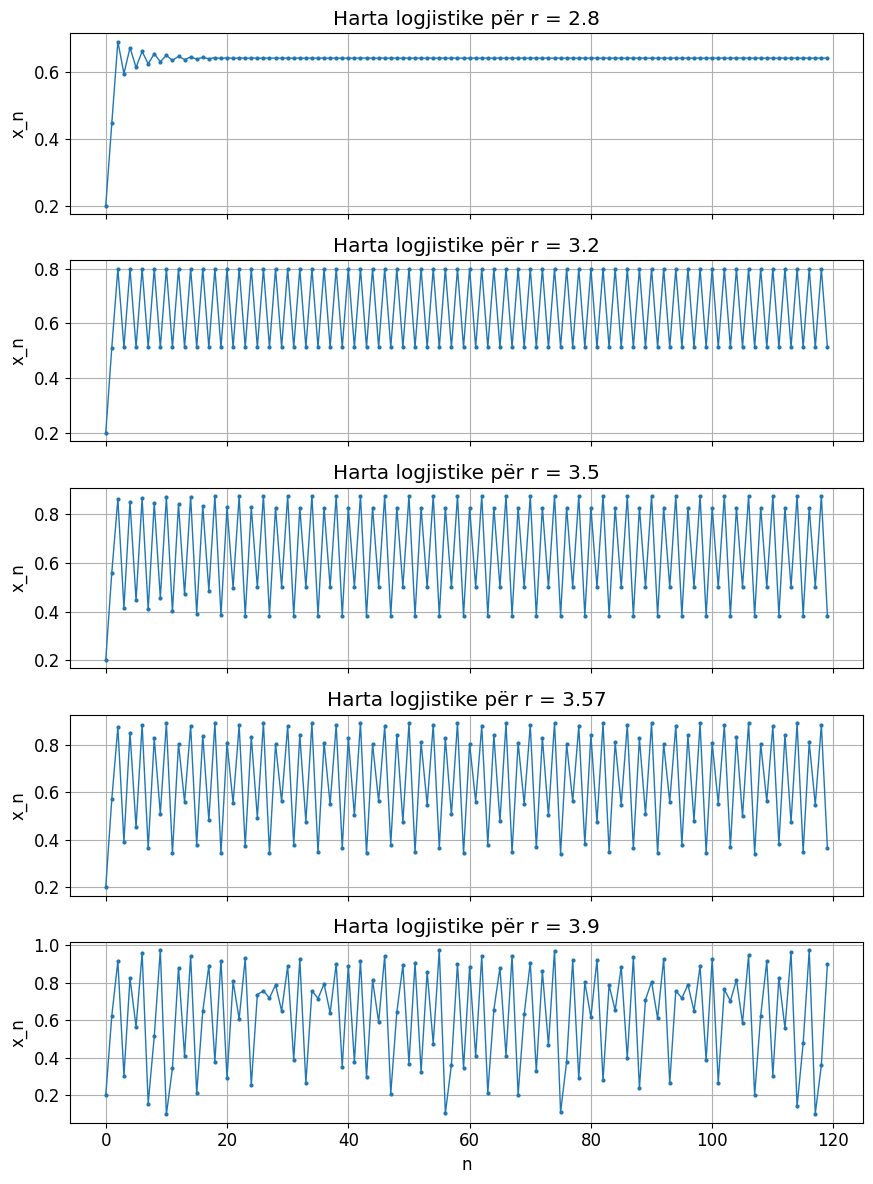

In [3]:
r_values = [2.8, 3.2, 3.5, 3.57, 3.9]
x0 = 0.2
n = 120

fig, axes = plt.subplots(len(r_values), 1, figsize=(9, 12), sharex=True)

for ax, r in zip(axes, r_values):
    x = iterate_logistic(r, x0=x0, n=n)
    ax.plot(np.arange(n), x, marker="o", markersize=2, linewidth=1)
    ax.set_ylabel("x_n")
    ax.set_title(f"Harta logjistike për r = {r}")

axes[-1].set_xlabel("n")
plt.tight_layout()
plt.show()

### Interpretim

- Për $r = 2.8$, sistemi shkon drejt një **pike fikse stabile**.
- Për $r = 3.2$, shfaqet një **orbitë me periudhë 2**.
- Për $r = 3.5$, kemi zakonisht një **periudhë 4** ose sjellje periodike më komplekse.
- Afër $r \approx 3.57$, fillon regjimi kaotik klasik.
- Për $r = 3.9$, sjellja bëhet fuqishëm joperiodike dhe shumë e ndjeshme ndaj kushteve fillestare.

Ky kalim progresiv është një demonstrim i drejtpërdrejtë i skenarit të famshëm të **Feigenbaum-it**, ku sistemi humb stabilitetin përmes **dyfishimeve të njëpasnjëshme të periudhës**.

## 3. Diagrami i bifurkacionit

Diagrami i bifurkacionit është një nga paraqitjet më të fuqishme në dinamikën jolineare. Për çdo vlerë të parametrës $r$, sistemi iterohet shumë herë; pjesa tranzitore hidhet poshtë dhe vizatohen vetëm vlerat asimptotike të $x_n$.

Kjo lejon të shohim në një figurë të vetme:
- regjimet me pikë fikse,
- orbitat periodike,
- kaskadën e bifurkacioneve,
- dritaret periodike,
- regjimin kaotik.

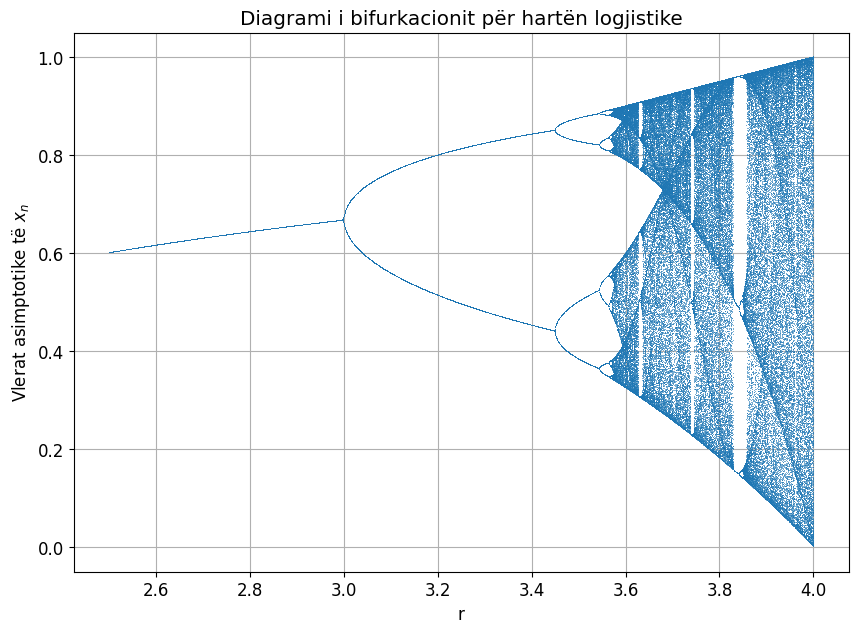

In [4]:
def bifurcation_data(r_min=2.5, r_max=4.0, nr=2500, x0=0.2, n_transient=1000, n_keep=200):
    rs = np.linspace(r_min, r_max, nr)
    R, X = [], []
    for r in rs:
        x = x0
        for _ in range(n_transient):
            x = logistic_map(x, r)
        for _ in range(n_keep):
            x = logistic_map(x, r)
            R.append(r)
            X.append(x)
    return np.array(R), np.array(X)

R, X = bifurcation_data()

plt.figure(figsize=(10, 7))
plt.plot(R, X, ",", alpha=0.6)
plt.xlabel("r")
plt.ylabel("Vlerat asimptotike të $x_n$")
plt.title("Diagrami i bifurkacionit për hartën logjistike")
plt.show()

### Koment fizik-matematikor

Diagrami i bifurkacionit përmban një sasi të jashtëzakonshme informacioni strukturor. Vihen re qartë:

1. **regjimi monostabil** për vlera të vogla të $r$;
2. **bifurkacioni i parë** ku pika fikse humb stabilitetin;
3. **kaskada e dyfishimeve të periudhës**;
4. **kalimi në kaos**;
5. **dritare periodike** brenda regjimit kaotik;
6. **vetëngjashmëria** në shkallë të ndryshme, e lidhur me universalitetin e Feigenbaum-it.

Ky është një shembull i mrekullueshëm se si një ekuacion jashtëzakonisht i thjeshtë mund të gjenerojë struktura të pasura, komplekse dhe universale.

## 4. Ndjeshmëria ndaj kushteve fillestare

Për të demonstruar konceptin e kaosit, krahasojmë dy trajektore që ndryshojnë vetëm me një perturbim shumë të vogël në gjendjen fillestare:
$
x_0' = x_0 + \varepsilon,
\qquad \varepsilon \ll 1.
$

Në regjimin kaotik, diferenca midis tyre mund të rritet shumë shpejt.

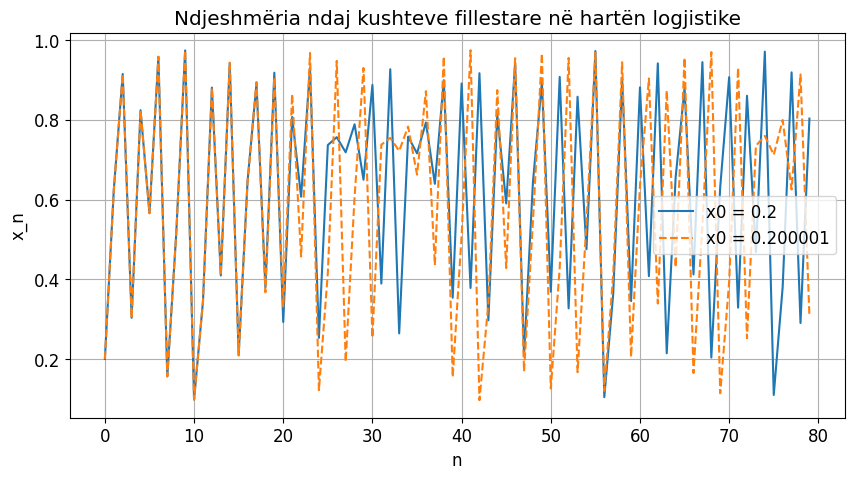

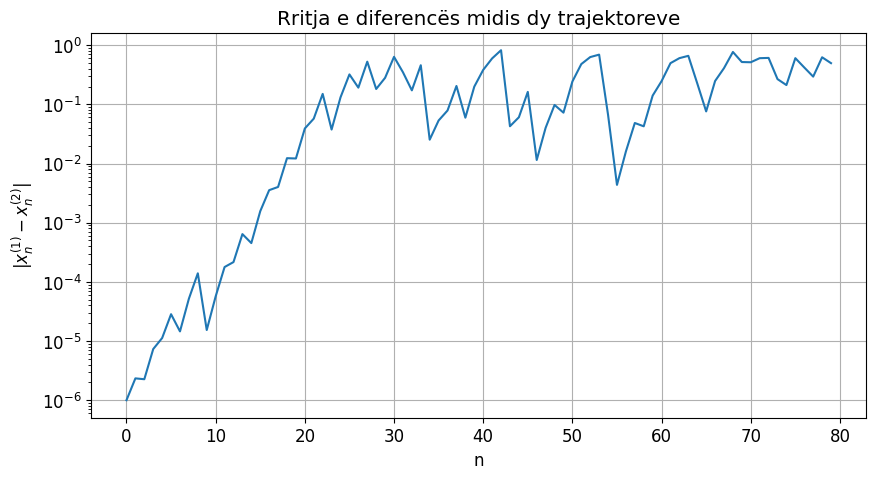

In [5]:
r = 3.9
x0_1 = 0.200000
x0_2 = 0.200001
n = 80

x1 = iterate_logistic(r, x0=x0_1, n=n)
x2 = iterate_logistic(r, x0=x0_2, n=n)

plt.figure(figsize=(10, 5))
plt.plot(x1, label=f"x0 = {x0_1}")
plt.plot(x2, "--", label=f"x0 = {x0_2}")
plt.xlabel("n")
plt.ylabel("x_n")
plt.title("Ndjeshmëria ndaj kushteve fillestare në hartën logjistike")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
difference = np.abs(x1 - x2)
plt.semilogy(difference + 1e-16)
plt.xlabel("n")
plt.ylabel(r"$|x_n^{(1)} - x_n^{(2)}|$")
plt.title("Rritja e diferencës midis dy trajektoreve")
plt.show()

Në grafikët e mësipërm vihet re se dy trajektore që fillojnë pothuajse në të njëjtën pikë mbeten të afërta vetëm për pak iterime. Më tej, ato ndahen fuqishëm. Kjo është shenja operative e **ndjeshmërisë ndaj kushteve fillestare**.

Është shumë e rëndësishme të theksohet se kjo **nuk do të thotë** mungesë ligjshmërie. Përkundrazi, të dyja trajektoret respektojnë saktësisht të njëjtin ligj dinamik. Vështirësia lind nga fakti se gabimet, pasaktësitë numerike ose matëse zmadhohen shpejt.

## 5. Eksponenti i Ljapunovit për hartën logjistike

Për një hartë njëdimensionale
$
x_{n+1} = f(x_n),
$
eksponenti i Ljapunovit vlerësohet nga formula
$$
\lambda = \lim_{N\to\infty} \frac{1}{N} \sum_{n=0}^{N-1}\ln|f'(x_n)|.
$$

Për hartën logjistike:
$$
f(x) = r x(1-x), \qquad f'(x)=r(1-2x).
$$

Në praktikë, limiti zëvendësohet nga një mesatare për një numër të madh iterimesh pas heqjes së tranzientit.

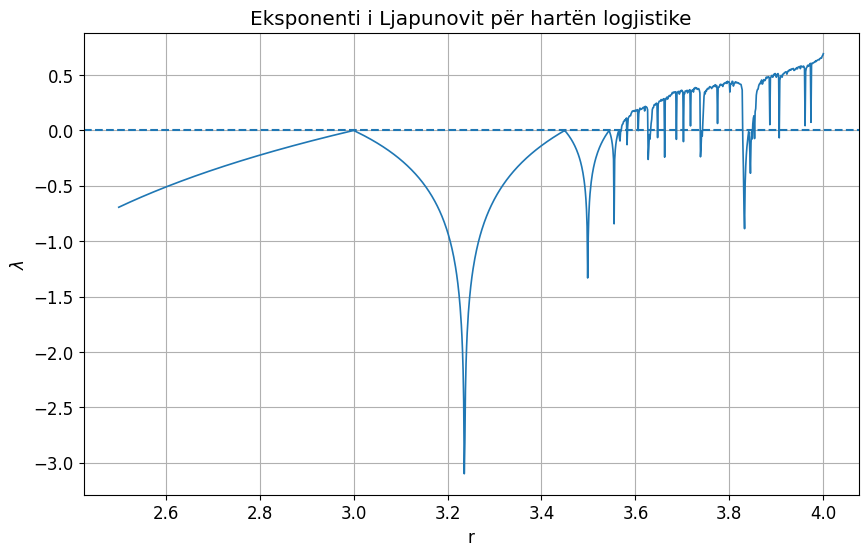

In [6]:
def logistic_lyapunov(r, x0=0.2, n_transient=1000, n_eval=5000):
    x = x0
    for _ in range(n_transient):
        x = logistic_map(x, r)

    s = 0.0
    for _ in range(n_eval):
        x = logistic_map(x, r)
        deriv = abs(r * (1 - 2*x))
        s += np.log(deriv + 1e-16)
    return s / n_eval

r_scan = np.linspace(2.5, 4.0, 1200)
lyap = np.array([logistic_lyapunov(r) for r in r_scan])

plt.figure(figsize=(10, 6))
plt.plot(r_scan, lyap, linewidth=1.2)
plt.axhline(0.0, linestyle="--")
plt.xlabel("r")
plt.ylabel(r"$\lambda$")
plt.title("Eksponenti i Ljapunovit për hartën logjistike")
plt.show()

### Interpretim i shenjës së $\lambda$

- $\lambda < 0$: trajektoret priren të afrohen; regjimi është zakonisht stabil.
- $\lambda = 0$: shpesh jemi pranë kalimeve kritike ose orbitave kufitare.
- $\lambda > 0$: kemi ndarje eksponenciale të trajektoreve dhe prani të kaosit.

Ky grafik është një plotësues natyror i diagramit të bifurkacionit. Zonat ku $\lambda > 0$ përputhen në përgjithësi me regjimet kaotike, ndërsa zonat ku $\lambda < 0$ tregojnë sjellje periodike ose pika fikse.

## 6. Portreti i fazës dhe sistemi i Lorencit

Për të kaluar nga një sistem diskret në një sistem të vazhduar, shqyrtojmë **sistemin e Lorencit**, një model klasik në meteorologji dhe dinamikë jolineare:
$$
\dot{x} = \sigma (y-x),
$$
$$
\dot{y} = x(\rho-z)-y,
$$
$$
\dot{z} = xy-\beta z.
$$

Për parametrat klasikë
$$
\sigma = 10,\qquad \rho = 28,\qquad \beta = \frac{8}{3},
$$
sistemi paraqet një nga tërheqësit kaotikë më të famshëm në histori.

In [17]:
def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz], dtype=float)

sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

t, sol = integrate_ode(lorenz, y0=np.array([1.0, 1.0, 1.0]), t0=0.0, t1=40.0, dt=0.01, sigma, rho, beta)
x, y, z = sol[:,0], sol[:,1], sol[:,2]

SyntaxError: positional argument follows keyword argument (149919657.py, line 12)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # vetëm për aktivizim 3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x, y, z, linewidth=0.6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Tërheqësi i Lorencit")
plt.show()

### Çfarë vërejmë?

Trajektorja nuk mbyllet në një orbitë periodike të thjeshtë, por gjithashtu nuk largohet në pafundësi. Ajo mbetet e kufizuar në një zonë të hapësirës së fazës dhe lëviz në mënyrë të ndërlikuar rreth dy “krahëve” të tërheqësit.

Ky objekt quhet **tërheqës i çuditshëm** (*strange attractor*), sepse bashkon dy tipare:
- tërheq trajektore nga një klasë kushtesh fillestare;
- ka gjeometri të ndërlikuar, zakonisht fraktale.

Ky është një nga simbolet qendrore të kaosit determinist.

## 7. Ndjeshmëria ndaj kushteve fillestare në sistemin e Lorencit

Ashtu si te harta logjistike, krahasojmë dy trajektore shumë të afërta në kohën fillestare.

In [ ]:
t1, sol1 = integrate_ode(lorenz, y0=np.array([1.0, 1.0, 1.0]), t0=0.0, t1=30.0, dt=0.01, sigma=sigma, rho=rho, beta=beta)
t2, sol2 = integrate_ode(lorenz, y0=np.array([1.0, 1.0, 1.00001]), t0=0.0, t1=30.0, dt=0.01, sigma=sigma, rho=rho, beta=beta)

dist = np.linalg.norm(sol1 - sol2, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(t1, sol1[:,0], label="x(t), trajektorja 1")
plt.plot(t2, sol2[:,0], "--", label="x(t), trajektorja 2")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Krahasimi i dy trajektoreve shumë të afërta")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.semilogy(t1, dist + 1e-16)
plt.xlabel("t")
plt.ylabel("Distanca në hapësirën e fazës")
plt.title("Rritja e largësisë midis dy trajektoreve")
plt.show()

Në kohë të shkurtra trajektoret janë pothuajse të padallueshme. Më tej, divergjenca rritet fuqishëm. Ky është versioni i vazhduar i të njëjtit fenomen që pamë te harta logjistike.

Në kontekstin fizik, ky fakt është tejet i rëndësishëm. Për shembull, në modele atmosferike, një gabim shumë i vogël në matjen fillestare të gjendjes mund të kufizojë rëndë horizontin e parashikimit.

## 8. Seksion i shkurtër teorik: nga rendi në kaos

Kalimi nga rendi në kaos nuk ndodh në një mënyrë unike. Në dinamikën jolineare njihen disa rrugë tipike:

1. **dyfishimi i periudhës** (*period doubling*);
2. **rruga kuaziperiodike** përmes ndërveprimit të frekuencave jokomensure;
3. **intermitenca**;
4. **kriza dinamike**;
5. **mbivendosja e rezonancave** në sisteme Hamiltoniane.

Në këtë notebook kemi studiuar kryesisht rrugën e parë, e cila është ndër më të rëndësishmet dhe më pedagogjiket.

## 9. Lidhja me modelimin numerik

Studimi i sistemeve kaotike është i lidhur ngushtë me cilësinë e metodave numerike. Në praktikë duhet pasur kujdes për:

- zgjedhjen e hapit kohor $\Delta t$;
- akumulimin e gabimeve të rrumbullakimit;
- dallimin midis kaosit fizik dhe artefakteve numerike;
- kohëzgjatjen e tranzientit;
- kontrollin e varësisë nga kushtet fillestare;
- stabilitetin numerik të integratorit.

Në sistemet kaotike, krahasimi pikë më pikë i dy zgjidhjeve numerike ka kuptim vetëm në intervale kohore të kufizuara. Për kohë më të gjata, shpesh është më e përshtatshme të krahasohen:
- invariantët statistikorë,
- spektrat e frekuencave,
- shpërndarjet në hapësirën e fazës,
- eksponentët e Ljapunovit,
- dimensionet fraktale.

## 10. Ushtrime të sugjeruara për studentët

### Ushtrimi 1
Përsëritni diagramin e bifurkacionit për hartën logjistike duke përdorur vlera të ndryshme për:
- numrin e iterimeve tranzitore,
- numrin e pikave të ruajtura,
- kushtin fillestar $x_0$.

Diskutoni cilat ndryshime janë vetëm vizuale dhe cilat ndikojnë realisht interpretimin.

### Ushtrimi 2
Llogaritni eksponentin e Ljapunovit për disa vlera specifike të $r$, p.sh.
$
r = 3.2,\; 3.5,\; 3.57,\; 3.9.
$
Krahasoni shenjën e $\lambda$ me sjelljen që shihni në trajektoret kohore.

### Ushtrimi 3
Ndryshoni parametrin $\rho$ në sistemin e Lorencit dhe studioni si ndryshon forma e tërheqësit.

### Ushtrimi 4
Zgjidhni dy hapa kohorë të ndryshëm për integrimin e sistemit të Lorencit, p.sh. $\Delta t=0.01$ dhe $\Delta t=0.001$, dhe diskutoni dallimin midis:
- trajektores në kohë të shkurtër,
- sjelljes afatgjatë,
- shpërndarjes së pikave në hapësirën e fazës.

### Ushtrimi 5
Përgatisni një koment të shkurtër mbi pyetjen:
**Pse kaosi determinist nuk është kontradiktë logjike?**

## 11. Zgjerim i mundshëm për vijimin e kursit

Në vazhdim të kësaj pjese, mund të shtohen në mënyrë natyrale:

- **lavjerrësi i detyruar dhe i amortizuar** si shembull fizik më afër mekanikës klasike;
- **oscilatori i Duffing-ut**;
- **seksionet e Poincaré-së**;
- **spektri i fuqisë** për të dalluar periodiken nga kaotikja;
- **dimensioni fraktal** i tërheqësve;
- **sistemet Hamiltoniane kaotike** dhe kaosi në mekanikën qiellore.

Këto do ta lidhin më fort teorinë e kaosit me mekanikën analitike dhe modelimin fizik që kemi zhvilluar në pjesët e mëparshme të kursit.

## 12. Përfundime

Në këtë notebook u pa se:

- **thjeshtësia e ekuacioneve nuk garanton thjeshtësi të dinamikës**;
- kaosi mund të lindë në sisteme plotësisht deterministe;
- **ndjeshmëria ndaj kushteve fillestare** është qendrore për kuptimin e kaosit;
- **diagrami i bifurkacionit** dhe **eksponenti i Ljapunovit** janë mjete themelore të analizës;
- sistemet e vazhduara, si **Lorenci**, ofrojnë tërheqës kaotikë me strukturë të pasur gjeometrike.

Nga pikëpamja pedagogjike, teoria e kaosit është një urë shumë e fuqishme midis:
- mekanikës klasike,
- analizës numerike,
- sistemeve jolineare,
- modelimit shkencor modern.

Ajo u tregon studentëve se edhe ligje të thjeshta mund të prodhojnë sjellje me kompleksitet të jashtëzakonshëm.

---

## Shtojcë: funksione ndihmëse për eksplorim të lirë

Qelizat më poshtë i lëmë që studentët të eksperimentojnë lirisht me parametra të ndryshëm.

In [ ]:
# Eksperiment i lirë me hartën logjistike
r = 3.7
x0 = 0.2
n = 150

x = iterate_logistic(r, x0=x0, n=n)

plt.figure(figsize=(9, 4))
plt.plot(np.arange(n), x, marker="o", markersize=2, linewidth=1)
plt.xlabel("n")
plt.ylabel("x_n")
plt.title(f"Eksperiment i lirë: harta logjistike për r = {r}")
plt.show()

In [ ]:
# Eksperiment i lirë me parametrat e Lorencit
sigma_test = 10.0
rho_test = 28.0
beta_test = 8.0/3.0

t_test, sol_test = integrate_ode(
    lorenz,
    y0=np.array([1.0, 1.0, 1.0]),
    t0=0.0,
    t1=20.0,
    dt=0.01,
    sigma=sigma_test,
    rho=rho_test,
    beta=beta_test
)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(sol_test[:,0], sol_test[:,1], sol_test[:,2], linewidth=0.7)
ax.set_title("Eksperiment i lirë: tërheqësi i Lorencit")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()